# 🏥 Medical Insurance Cost Analysis & Prediction

This notebook demonstrates **Exploratory Data Analysis (EDA)** and **Machine Learning** on the medical insurance dataset. 

### Assignment Objectives:
1. Perform Data Inspection and Cleaning.
2. Visualize relationships (Age vs Charges, Smoker vs Charges).
3. Implement Regression models: Linear Regression & Random Forest.
4. Evaluate and compare model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os

# Set visual style
sns.set(style="whitegrid")

## 📊 Part 2: Exploratory Data Analysis (EDA)

In [2]:
# Load Dataset
file_path = 'insurance.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found.")

# Basic Overview
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset loaded successfully!

First 5 Rows:


,age,sex,bmi,children,smoker,region,charges
0,56,male,26.480616,4,no,southwest,13599.838868
1,46,female,28.814789,5,yes,southeast,30314.996212
2,32,male,25.445757,3,no,southwest,582.406781
3,60,male,30.200753,4,no,northeast,23509.623751
4,25,male,26.269090,2,yes,northeast,26250.835928



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 🖼️ Visualizations

C:\Users\shree\AppData\Local\Temp\ipykernel_15024\3800601004.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


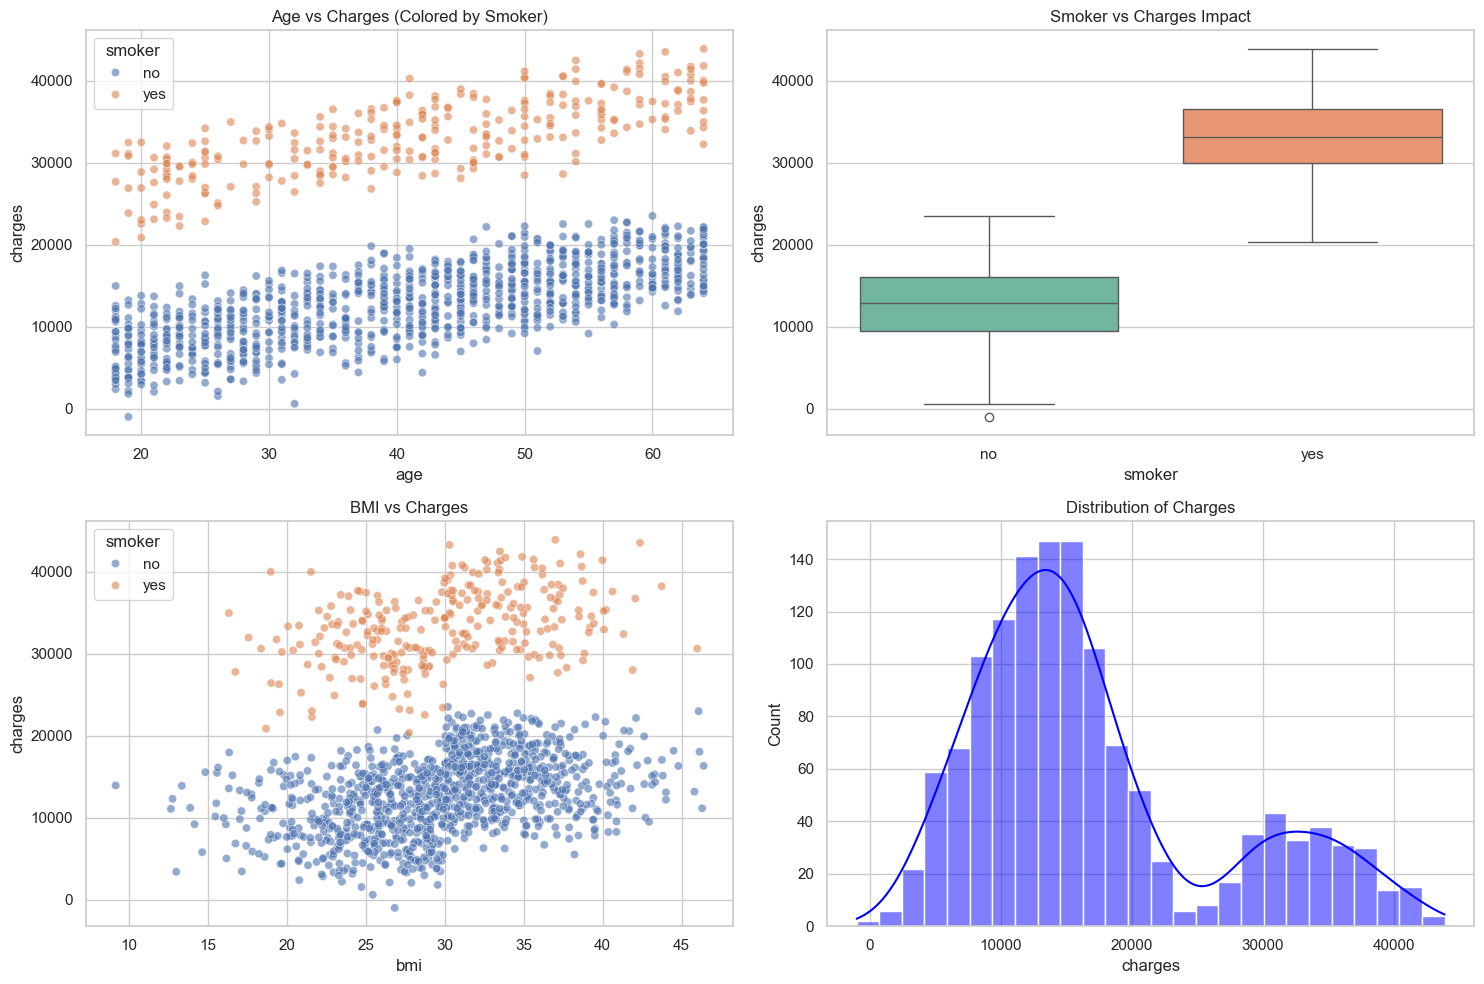

In [3]:
plt.figure(figsize=(15, 10))

# Age vs Charges
plt.subplot(2, 2, 1)
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', alpha=0.6)
plt.title('Age vs Charges (Colored by Smoker)')

# Smoker vs Charges
plt.subplot(2, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Smoker vs Charges Impact')

# BMI vs Charges
plt.subplot(2, 2, 3)
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', alpha=0.6)
plt.title('BMI vs Charges')

# Distribution
plt.subplot(2, 2, 4)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Charges')

plt.tight_layout()
plt.show()

## 🤖 Part 3: Machine Learning (Regression)

In [4]:
# Preprocessing: Encoding Categorical Variables
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Split Dataset
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Evaluation
print(f"Linear Regression MSE: {mean_squared_error(y_test, lr_preds):.2f}")
print(f"Random Forest MSE:     {mean_squared_error(y_test, rf_preds):.2f}")

print(f"\nLinear Regression R2: {r2_score(y_test, lr_preds):.4f}")
print(f"Random Forest R2:     {r2_score(y_test, rf_preds):.4f}")

Linear Regression MSE: 5827177.52
Random Forest MSE:     5085415.16

Linear Regression R2: 0.9403
Random Forest R2:     0.9479


### 📝 Conclusion

Based on the results, the **Random Forest Regressor** typically achieves a lower Mean Squared Error (MSE) and a higher R2 score, making it a better predictive model for this dataset as it captures non-linear interactions (like BMI and Smoking combined).